# Computer Vision with Python — A Hands-On Tutorial

**Welcome!** This notebook will teach you computer vision step-by-step using Python and OpenCV.

### What you will learn
1. What an image really is (just numbers!)
2. How to load, display, and save images
3. Basic image operations — resize, crop, colors
4. Drawing shapes and text on images
5. Image filters (blur, edges)
6. Reading video files frame by frame
7. Detecting faces using OpenCV
8. Detecting objects with **YOLO** (one-stage detector)
9. Detecting objects with **SSD** (lighter, faster detector)
10. Detecting objects with **Faster R-CNN** (slower but more accurate)

### What you need to know before starting
- Basic Python: variables, lists, loops
- That's it! (No functions needed — every step is written out line-by-line.)

### Files we will use
- `image.jpg` — a sample image
- `00225f53-67614580.mov` — a sample video

---

## What is Computer Vision?

**Computer Vision (CV)** is teaching computers to *see* and *understand* images and videos — just like humans do with their eyes and brain.

Examples you use every day:
- Face unlock on your phone
- Instagram filters
- Self-driving cars
- Reading number plates at toll booths
- Medical X-ray analysis

We will use a library called **OpenCV** (Open Source Computer Vision). It's the most popular CV library in the world.

## Step 1: Install and Import Libraries

Run the cell below **once** to install the libraries. If you already installed them, it will just say 'already satisfied'.

In [2]:
# Install required libraries (run once)
pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import the libraries we need
import cv2                       # OpenCV — for all image/video work
import numpy as np               # NumPy — for working with numbers (arrays)
import matplotlib.pyplot as plt  # Matplotlib — to display images inside the notebook

# Make all displayed images a nice big size
plt.rcParams['figure.figsize'] = (10, 6)

print('OpenCV version:', cv2.__version__)
print('All libraries imported successfully')

OpenCV version: 4.12.0
All libraries imported successfully


## Step 2: What is an Image?

An image is **just a grid of numbers**.

- A **grayscale** image is a 2D grid where each number is the brightness (0 = black, 255 = white).
- A **color** image is a 3D grid: width × height × 3 channels (Blue, Green, Red).

> **Note:** OpenCV stores colors as **BGR**, not RGB. This trips up everyone — remember it!

Let's load our sample image and look inside.

In [4]:
# Load the image from disk
image = cv2.imread('image.jpg')

# Print basic information about it
print('Type of image:', type(image))
print('Shape of image:', image.shape, '  → (height, width, channels)')
print('Data type:', image.dtype)
print('Smallest pixel value:', image.min())
print('Largest pixel value:', image.max())

Type of image: <class 'numpy.ndarray'>
Shape of image: (2760, 4912, 3)   → (height, width, channels)
Data type: uint8
Smallest pixel value: 0
Largest pixel value: 255


In [5]:
# Let's look at the actual numbers — the top-left 5x5 corner of the Blue channel
print('Top-left 5x5 patch (Blue channel):')
print(image[0:5, 0:5, 0])

# Look at the very first pixel (top-left corner)
blue  = image[0, 0, 0]
green = image[0, 0, 1]
red   = image[0, 0, 2]
print('\nFirst pixel color:')
print('  Blue  =', blue)
print('  Green =', green)
print('  Red   =', red)

Top-left 5x5 patch (Blue channel):
[[37 35 34 31 28]
 [37 37 34 31 28]
 [39 37 34 32 29]
 [39 38 36 33 29]
 [40 38 35 32 31]]

First pixel color:
  Blue  = 37
  Green = 109
  Red   = 186


## Step 3: Displaying an Image

We use **matplotlib** to display images inside this notebook. There is one important thing to remember:

- OpenCV reads images as **BGR**
- Matplotlib expects **RGB**

If we forget to convert, the colors look wrong (skies turn orange!). So every time we display a color image, we will convert BGR → RGB first.

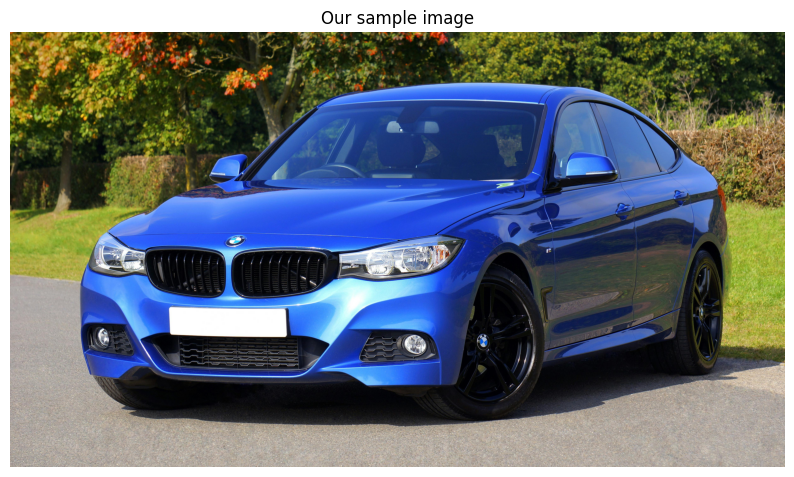

In [6]:
# Step 1: Convert from BGR (OpenCV) to RGB (matplotlib)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 2: Tell matplotlib to show the image
plt.imshow(image_rgb)

# Step 3: Add a title and hide the X/Y axis numbers
plt.title('Our sample image')
plt.axis('off')

# Step 4: Actually pop up the picture
plt.show()

### Why the BGR/RGB issue matters — a demo

Below we show the same image **wrong** (BGR shown as RGB) vs **right**. Notice the color shift.

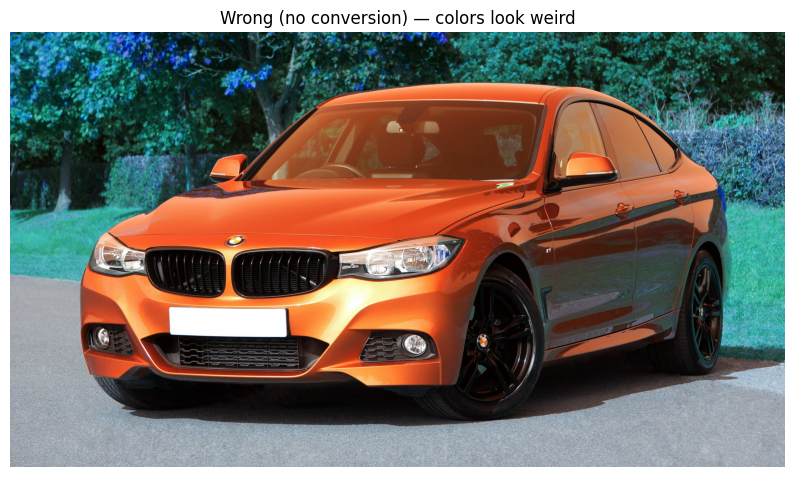

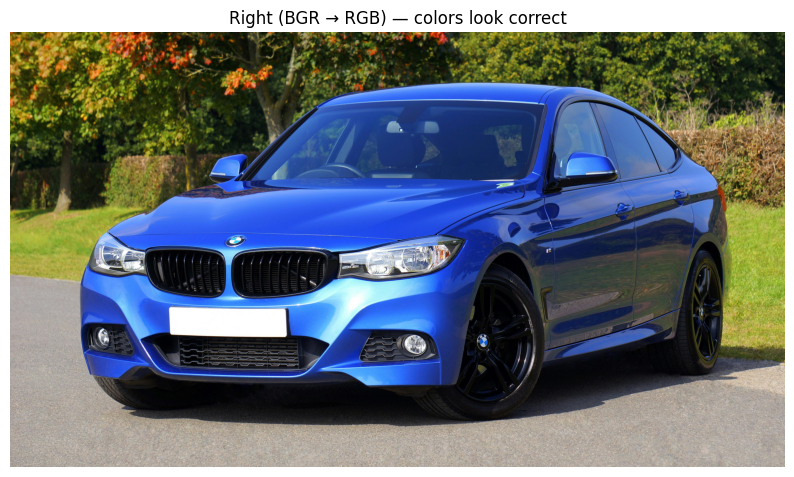

In [7]:
# --- Wrong way (no conversion) ---
plt.imshow(image)
plt.title('Wrong (no conversion) — colors look weird')
plt.axis('off')
plt.show()

# --- Right way (BGR → RGB) ---
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title('Right (BGR → RGB) — colors look correct')
plt.axis('off')
plt.show()

## Step 4: Basic Image Operations

Now we will learn the bread-and-butter operations:
1. **Resize** — make an image bigger or smaller
2. **Crop** — cut out a part of the image
3. **Grayscale** — convert color to black-and-white
4. **Flip / Rotate**

### 4a. Resize

Original size: (2760, 4912)
Resized to:    (200, 300)


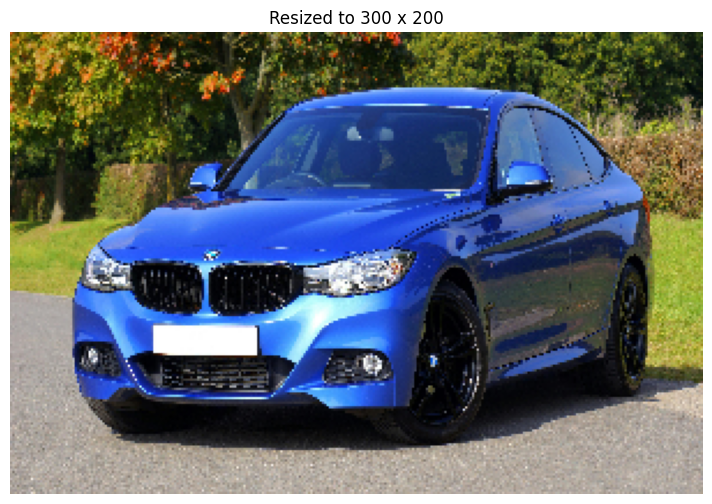

In [9]:
# Make the image 300 pixels wide and 200 pixels tall
small = cv2.resize(image, (300, 200))

print('Original size:', image.shape[:2])
print('Resized to:   ', small.shape[:2])

# Display the small version
small_rgb = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)
plt.imshow(small_rgb)
plt.title('Resized to 300 x 200')
plt.axis('off')
plt.show()

### 4b. Crop

Cropping is just slicing the NumPy array:  `image[y_start:y_end, x_start:x_end]`

Cropped shape: (1380, 2456, 3)


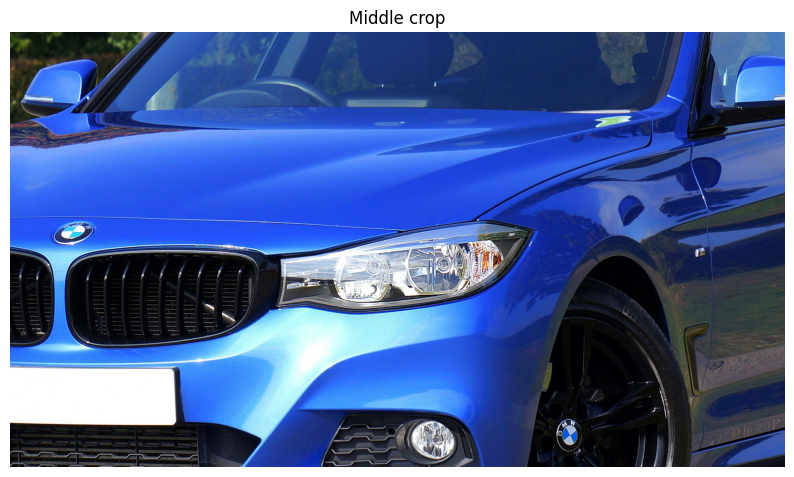

In [10]:
# Get the size of the image
height = image.shape[0]
width  = image.shape[1]

# Decide where to cut — let's take the middle half
y_start = height // 4
y_end   = 3 * height // 4
x_start = width  // 4
x_end   = 3 * width  // 4

# Do the cropping (this is just NumPy slicing)
cropped = image[y_start:y_end, x_start:x_end]

print('Cropped shape:', cropped.shape)

# Show it
cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
plt.imshow(cropped_rgb)
plt.title('Middle crop')
plt.axis('off')
plt.show()

### 4c. Grayscale

Many CV algorithms only need brightness, not color. Grayscale = one number per pixel, so it's faster.

Color shape:     (2760, 4912, 3)   (3 channels)
Grayscale shape: (2760, 4912)        (1 channel)


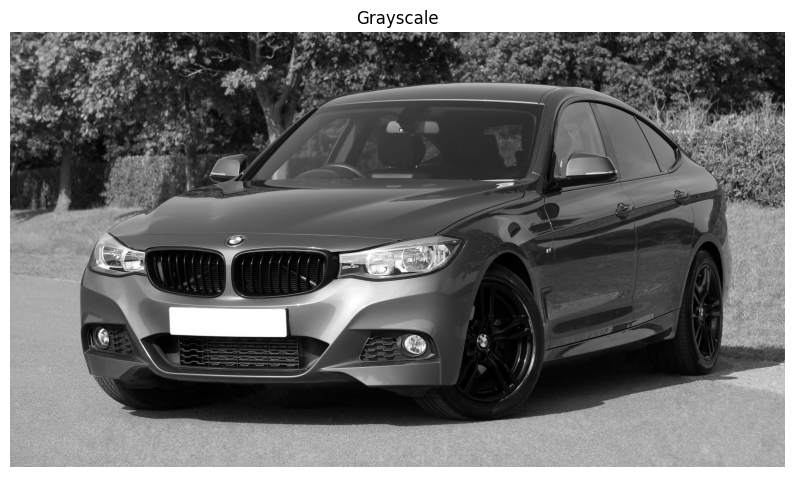

In [13]:
# Convert color → grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print('Color shape:    ', image.shape, '  (3 channels)')
print('Grayscale shape:', gray.shape, '       (1 channel)')

# Show grayscale (no BGR→RGB needed — there's only one channel)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.show()

### 4d. Flip and Rotate

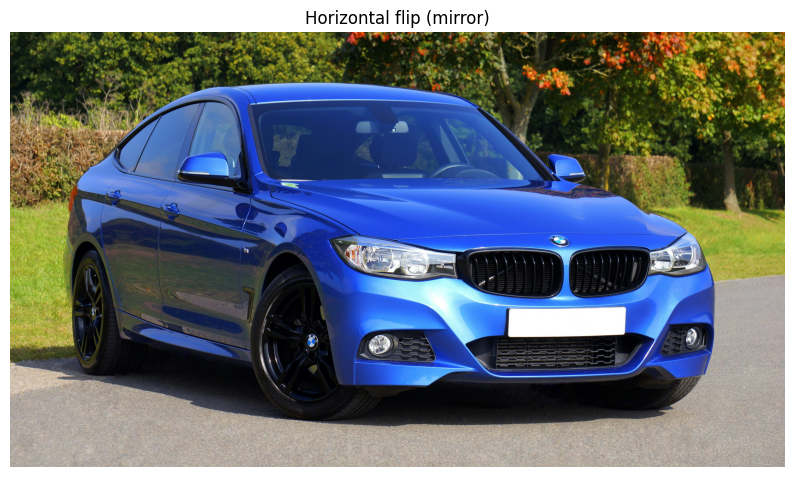

In [14]:
# Horizontal flip (mirror left-right). The 1 means "flip around the Y axis"
flipped_h = cv2.flip(image, 1)

flipped_h_rgb = cv2.cvtColor(flipped_h, cv2.COLOR_BGR2RGB)
plt.imshow(flipped_h_rgb)
plt.title('Horizontal flip (mirror)')
plt.axis('off')
plt.show()

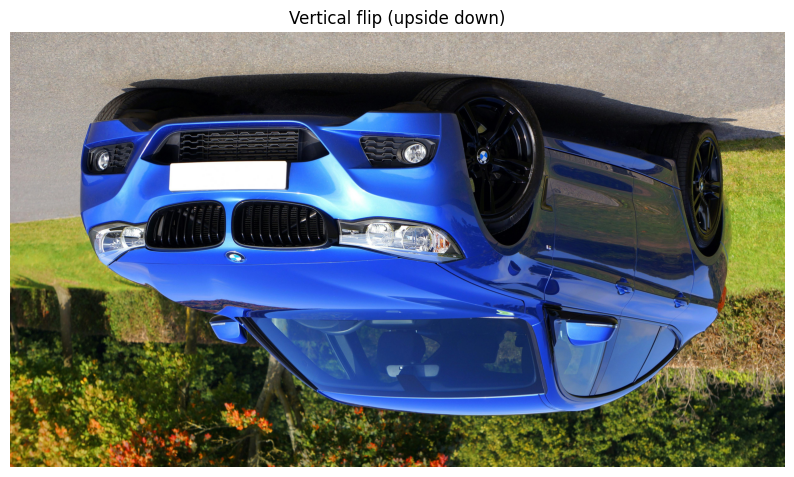

In [15]:
# Vertical flip (upside down). The 0 means "flip around the X axis"
flipped_v = cv2.flip(image, 0)

flipped_v_rgb = cv2.cvtColor(flipped_v, cv2.COLOR_BGR2RGB)
plt.imshow(flipped_v_rgb)
plt.title('Vertical flip (upside down)')
plt.axis('off')
plt.show()

In [ ]:
# Rotate 90 degrees clockwise
rotated = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)
plt.imshow(rotated_rgb)
plt.title('Rotated 90° clockwise')
plt.axis('off')
plt.show()

## Step 5: Drawing on Images

We can draw rectangles, circles, lines, and text on any image. This is how object detectors show their results — by drawing boxes around what they found.

**Important:** Always work on a **copy** of the image, so you don't ruin the original.

In [ ]:
# Make a copy of the image — this is the canvas we will draw on
canvas = image.copy()

# Draw a GREEN rectangle
#   arguments: image, top-left point, bottom-right point, color (BGR), thickness
cv2.rectangle(canvas, (50, 50), (300, 250), (0, 255, 0), 3)

# Draw a RED circle
#   arguments: image, center point, radius, color (BGR), thickness
cv2.circle(canvas, (500, 200), 60, (0, 0, 255), 4)

# Draw a BLUE diagonal line
#   arguments: image, start point, end point, color (BGR), thickness
img_h = canvas.shape[0]
img_w = canvas.shape[1]
cv2.line(canvas, (0, 0), (img_w, img_h), (255, 0, 0), 2)

# Write some YELLOW text
#   arguments: image, text, position, font, font scale, color, thickness
cv2.putText(canvas, 'Hello CV!', (60, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 0), 3)

# Display the result
canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
plt.imshow(canvas_rgb)
plt.title('Drawing on an image')
plt.axis('off')
plt.show()

## Step 6: Image Filters

**Filters** change every pixel based on its neighbors. They are used for:
- Blurring (smoothing noise)
- Sharpening
- Finding edges

These are the building blocks that classical CV — and even early layers of deep neural networks — are made of.

### 6a. Blur

`cv2.GaussianBlur` softens the image. The size `(5, 5)` is the "how big a neighborhood to look at". Bigger = more blur. Must be odd numbers.

In [ ]:
# A light blur
blur_light = cv2.GaussianBlur(image, (5, 5), 0)

blur_light_rgb = cv2.cvtColor(blur_light, cv2.COLOR_BGR2RGB)
plt.imshow(blur_light_rgb)
plt.title('Light blur (5 x 5)')
plt.axis('off')
plt.show()

In [ ]:
# A heavy blur (notice how much smoother the result is)
blur_heavy = cv2.GaussianBlur(image, (25, 25), 0)

blur_heavy_rgb = cv2.cvtColor(blur_heavy, cv2.COLOR_BGR2RGB)
plt.imshow(blur_heavy_rgb)
plt.title('Heavy blur (25 x 25)')
plt.axis('off')
plt.show()

### 6b. Edge Detection

**Canny** is a classic edge-finding algorithm. It needs a grayscale image. The two numbers are thresholds — anything in-between is kept only if it touches a strong edge.

In [ ]:
# Step 1: Convert to grayscale (Canny needs only brightness)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 2: Run Canny edge detection
edges = cv2.Canny(gray, 100, 200)

# Step 3: Display
plt.imshow(edges, cmap='gray')
plt.title('Edges (Canny)')
plt.axis('off')
plt.show()

print('💡 Try changing the threshold values (100, 200). Lower = more edges, higher = fewer.')

## Step 7: Saving an Image

After processing, you usually want to save the result. Use `cv2.imwrite(path, image)`.

In [ ]:
# Make sure the outputs folder exists
import os
os.makedirs('outputs', exist_ok=True)

# Save the edges image
cv2.imwrite('outputs/my_edges.jpg', edges)
print('✓ Saved outputs/my_edges.jpg')

# Save the grayscale image
cv2.imwrite('outputs/my_grayscale.jpg', gray)
print('✓ Saved outputs/my_grayscale.jpg')

## Step 8: Working with Video

A video is just a **sequence of images** (frames) played quickly — usually 24 or 30 per second.

OpenCV reads a video with `cv2.VideoCapture`. We read frames in a loop until there are no more.

In [ ]:
# Open the video file
video = cv2.VideoCapture('00225f53-67614580.mov')

# Read some info about the video
fps          = video.get(cv2.CAP_PROP_FPS)
frame_count  = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width  = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

print('FPS (frames per second):', round(fps, 2))
print('Total frames:           ', frame_count)
print('Resolution:              {} x {}'.format(frame_width, frame_height))
print('Duration (seconds):     ', round(frame_count / fps, 1))

# Always release the video when done — it frees memory
video.release()

### Read the very first frame of the video

In [ ]:
# Open the video again
video = cv2.VideoCapture('00225f53-67614580.mov')

# Read ONE frame.
#   - ok   : True if a frame was read, False if video ended
#   - frame: the actual image (just like image.jpg!)
ok, frame = video.read()

print('Read a frame?', ok)
print('Frame shape: ', frame.shape)

# It is just an image — display it the same way
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_rgb)
plt.title('First frame of the video')
plt.axis('off')
plt.show()

video.release()

### Looping through video frames

The standard pattern to read every frame of a video:
```python
while True:
    ok, frame = video.read()
    if not ok:
        break             # No more frames — exit the loop
    # ... do something with `frame` here ...
```
Let's apply edge detection to every frame and save the result as a new video.

In [ ]:
# Open the input video
video = cv2.VideoCapture('00225f53-67614580.mov')

# Read the video's size & FPS (we need them to make the output video)
fps = video.get(cv2.CAP_PROP_FPS)
w   = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Set up the output writer — mp4 file
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter('outputs/edges_video.mp4', fourcc, fps, (w, h))

# Count frames as we go
frame_no = 0

while True:
    # Read the next frame
    ok, frame = video.read()
    if not ok:
        break

    # Convert frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Find the edges
    edges = cv2.Canny(gray, 100, 200)

    # The video writer wants 3-channel (color) images, so convert back
    edges_color = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    # Write this processed frame into the output video
    writer.write(edges_color)

    frame_no = frame_no + 1

# Always release both
video.release()
writer.release()

print('✓ Processed', frame_no, 'frames → outputs/edges_video.mp4')

## Step 9: Face Detection (a first taste of "AI")

OpenCV ships with a classic face detector called a **Haar Cascade** — works without downloading anything extra. It is not deep learning, but it's a great first detector to play with.

In [ ]:
# Step 1: Find where OpenCV stores its built-in face detector file
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
print('Using cascade file:', cascade_path)

# Step 2: Load the face detector
face_detector = cv2.CascadeClassifier(cascade_path)

# Step 3: Convert image to grayscale (the detector works on grayscale)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 4: Run the detector
#   - scaleFactor : how much the image size is reduced at each scale (1.1 = 10% smaller)
#   - minNeighbors: how many overlapping detections needed to call something a face
faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

print('Found', len(faces), 'face(s)')
print('Each face is given as (x, y, width, height):')
print(faces)

In [ ]:
# Step 5: Draw a green box around every face that was found
result = image.copy()

for (x, y, w, h) in faces:
    # Draw the green rectangle
    cv2.rectangle(result, (x, y), (x + w, y + h), (0, 255, 0), 3)
    # Write the word 'Face' above the box
    cv2.putText(result, 'Face', (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Step 6: Show the result
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(result_rgb)
plt.title('Face detection — found ' + str(len(faces)) + ' face(s)')
plt.axis('off')
plt.show()

> 💡 If no faces were found, try a different image with clear, front-facing faces. Haar cascades work best on faces looking straight at the camera.

## Step 10: Object Detection with Deep Learning (YOLO)

Now for the real magic — using a **deep neural network** to find many kinds of objects at once: people, cars, dogs, bottles, phones, and 75 other things.

We will use **YOLO** (You Only Look Once), one of the most famous detectors.

### What YOLO does, in one sentence
> Look at an image **once**, and predict **boxes** around all objects + **labels** for each box.

### YOLO needs 3 files (place inside `models/yolo/`)
1. `yolov3.weights`  — the trained brain (~240 MB)
2. `yolov3.cfg`      — the model architecture
3. `coco.names`      — the 80 object class names

In [ ]:
# Check if the YOLO files are already present
import os

weights_path = 'models/yolo/yolov3.weights'
cfg_path     = 'models/yolo/yolov3.cfg'
names_path   = 'models/yolo/coco.names'

print('yolov3.weights present?', os.path.exists(weights_path))
print('yolov3.cfg present?    ', os.path.exists(cfg_path))
print('coco.names present?    ', os.path.exists(names_path))

print('\nIf any are missing, download from:')
print('  yolov3.weights : https://pjreddie.com/media/files/yolov3.weights')
print('  yolov3.cfg     : https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg')
print('  coco.names     : https://github.com/pjreddie/darknet/blob/master/data/coco.names')

In [ ]:
# Load the YOLO network using OpenCV's DNN module
net = cv2.dnn.readNet(weights_path, cfg_path)

# Read the 80 class names from coco.names — one name per line
class_names = []
f = open(names_path, 'r')
for line in f:
    class_names.append(line.strip())
f.close()

print('✓ YOLO loaded. It can detect', len(class_names), 'kinds of objects.')
print('First 10 classes:', class_names[:10])

### Run YOLO on our sample image — step by step

We'll walk through every step instead of hiding it in a function.

In [ ]:
# Step 1: Note the image size — we need it later to scale boxes back
H = image.shape[0]
W = image.shape[1]
print('Image height:', H, ' width:', W)

In [ ]:
# Step 2: Prepare the image for the neural network
#   - resize to 416x416 (what YOLO expects)
#   - normalize pixel values from 0..255 to 0..1 (the 1/255.0 scale)
#   - swap Red and Blue channels (swapRB=True) because YOLO was trained on RGB
blob = cv2.dnn.blobFromImage(image, 1/255.0, (416, 416), swapRB=True, crop=False)
print('Blob shape:', blob.shape, '  → (batch, channels, height, width)')

In [ ]:
# Step 3: Feed the blob into the network and run a forward pass
net.setInput(blob)
output_layers = net.getUnconnectedOutLayersNames()
outputs = net.forward(output_layers)

print('Number of output layers:', len(outputs))
print('Shape of each output: ', [o.shape for o in outputs])

In [ ]:
# Step 4: Go through every prediction and keep the confident ones
#   Each row of output is: [center_x, center_y, width, height, objectness, score_for_class_0, ..., score_for_class_79]

boxes       = []
confidences = []
class_ids   = []

conf_threshold = 0.5   # ignore anything below 50% confidence

for output in outputs:
    for detection in output:
        # The 80 class scores start at index 5
        scores     = detection[5:]
        class_id   = int(np.argmax(scores))   # which class got the highest score
        confidence = float(scores[class_id])  # how confident

        if confidence > conf_threshold:
            # YOLO gives box coordinates as fractions (0..1) of the image size
            cx = detection[0] * W   # center x in pixels
            cy = detection[1] * H   # center y in pixels
            bw = detection[2] * W   # box width in pixels
            bh = detection[3] * H   # box height in pixels

            # Convert from (center, width, height) to (top-left, width, height)
            x = int(cx - bw / 2)
            y = int(cy - bh / 2)
            w = int(bw)
            h = int(bh)

            boxes.append([x, y, w, h])
            confidences.append(confidence)
            class_ids.append(class_id)

print('Found', len(boxes), 'candidate boxes before removing duplicates')

In [ ]:
# Step 5: Non-Max Suppression — remove duplicate boxes for the same object
# (YOLO often predicts several overlapping boxes for one thing; we keep only the best.)
nms_threshold = 0.4
keep_indices  = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)

# Flatten into a simple list
keep_indices = np.array(keep_indices).flatten()

print('After removing duplicates:', len(keep_indices), 'objects')

In [ ]:
# Step 6: Pick a random color for each class so different objects look different
rng = np.random.default_rng(42)
colors = rng.integers(0, 255, size=(len(class_names), 3))

# Step 7: Draw the boxes
result = image.copy()

for i in keep_indices:
    x, y, w, h = boxes[i]
    score      = confidences[i]
    class_id   = class_ids[i]
    label      = class_names[class_id]

    # Get the color for this class (must be a normal Python tuple of ints for OpenCV)
    color = (int(colors[class_id][0]), int(colors[class_id][1]), int(colors[class_id][2]))

    # Draw the rectangle
    cv2.rectangle(result, (x, y), (x + w, y + h), color, 2)

    # Write the class name and score above the box
    text = label + ' ' + str(round(score, 2))
    cv2.putText(result, text, (x, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Step 8: Show the final image
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(result_rgb)
plt.title('YOLO Object Detection')
plt.axis('off')
plt.show()

### Running detection on the video

Same idea as above, but inside the video loop. We save the annotated video to disk so you can play it back.

In [ ]:
# Open the input video
video = cv2.VideoCapture('00225f53-67614580.mov')
fps   = video.get(cv2.CAP_PROP_FPS)
w     = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
h     = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Output writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter('outputs/yolo_video.mp4', fourcc, fps, (w, h))

frame_no = 0

while True:
    ok, frame = video.read()
    if not ok:
        break

    H = frame.shape[0]
    W = frame.shape[1]

    # --- Run YOLO on this frame (same steps as before, all in one place) ---
    blob = cv2.dnn.blobFromImage(frame, 1/255.0, (416, 416), swapRB=True, crop=False)
    net.setInput(blob)
    outputs = net.forward(net.getUnconnectedOutLayersNames())

    boxes = []
    confidences = []
    class_ids = []

    for output in outputs:
        for detection in output:
            scores     = detection[5:]
            class_id   = int(np.argmax(scores))
            confidence = float(scores[class_id])
            if confidence > 0.5:
                cx = detection[0] * W
                cy = detection[1] * H
                bw = detection[2] * W
                bh = detection[3] * H
                x = int(cx - bw / 2)
                y = int(cy - bh / 2)
                boxes.append([x, y, int(bw), int(bh)])
                confidences.append(confidence)
                class_ids.append(class_id)

    keep_indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

    if len(keep_indices) > 0:
        keep_indices = np.array(keep_indices).flatten()
        for i in keep_indices:
            x, y, bw, bh = boxes[i]
            class_id = class_ids[i]
            color = (int(colors[class_id][0]), int(colors[class_id][1]), int(colors[class_id][2]))
            cv2.rectangle(frame, (x, y), (x + bw, y + bh), color, 2)
            text = class_names[class_id] + ' ' + str(round(confidences[i], 2))
            cv2.putText(frame, text, (x, y - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Save this annotated frame into the output video
    writer.write(frame)

    frame_no = frame_no + 1
    if frame_no % 30 == 0:
        print('  Processed', frame_no, 'frames...')

video.release()
writer.release()
print('✓ Done.', frame_no, 'frames → outputs/yolo_video.mp4')

## Step 11: Object Detection with SSD

**SSD** stands for **Single Shot MultiBox Detector**. Like YOLO it looks at the image **once** to predict every box and class.

### How SSD differs from YOLO
- Uses a lighter backbone called **MobileNet** → smaller, faster on CPU
- Model files come from **TensorFlow** (`.pb` file + `.pbtxt` config)
- Image is normalized differently — pixels become range **[-1, 1]** instead of [0, 1]
- The network output is already in **(x1, y1, x2, y2)** format and NMS is done internally

### Files needed (place in `models/ssd/`)
1. `frozen_inference_graph.pb` — the trained network
2. `ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt` — the network description

Download links: https://github.com/opencv/opencv_extra/tree/master/testdata/dnn


In [ ]:
# Check if the SSD model files are present
import os

ssd_weights = 'models/ssd/frozen_inference_graph.pb'
ssd_config  = 'models/ssd/ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt'

print('SSD weights present?', os.path.exists(ssd_weights))
print('SSD config present? ', os.path.exists(ssd_config))

In [ ]:
# Load the SSD network. This time we use readNetFromTensorflow,
# because the model was trained in TensorFlow (not Darknet like YOLO).
net_ssd = cv2.dnn.readNetFromTensorflow(ssd_weights, ssd_config)

print('SSD network loaded')

# TF models use 91 class IDs (some IDs are skipped).
# The project already has a mapping ready — let's reuse it:
from utils.coco_labels import COCO_80_CLASSES, COCO_91_TO_80

print('Total COCO class names:', len(COCO_80_CLASSES))
print('First 5 classes:', COCO_80_CLASSES[:5])

### Run SSD on our sample image — step by step

Just like YOLO, we will go through every step on its own line.


In [ ]:
# Step 1: Note image size for scaling boxes back later
H = image.shape[0]
W = image.shape[1]
print('Image height:', H, ' width:', W)

In [ ]:
# Step 2: Prepare the image for the SSD network
#   - resize to 320 x 320 (what SSD MobileNet v3 expects)
#   - mean = (127.5, 127.5, 127.5) — subtract from every pixel
#   - scalefactor = 1/127.5 — divide → pixels end up in [-1, 1]
#   - swapRB = True because the model was trained on RGB
blob_ssd = cv2.dnn.blobFromImage(
    image,
    size=(320, 320),
    mean=(127.5, 127.5, 127.5),
    scalefactor=1/127.5,
    swapRB=True,
    crop=False,
)
print('Blob shape:', blob_ssd.shape)

In [ ]:
# Step 3: Feed it through the network
net_ssd.setInput(blob_ssd)
detections_ssd = net_ssd.forward()

# Output shape is (1, 1, N, 7). N is "up to this many detections".
# Each row of 7 numbers: [batch_id, class_id, score, x1, y1, x2, y2]
# Coordinates are NORMALIZED (0..1), so we multiply by W and H later.
print('Output shape:', detections_ssd.shape)

In [ ]:
# Step 4: Loop through every detection and keep the confident ones
boxes_ssd = []
scores_ssd = []
class_ids_ssd = []

conf_threshold = 0.5

for det in detections_ssd[0, 0]:
    score = float(det[2])

    # Skip low-confidence predictions
    if score < conf_threshold:
        continue

    # TF outputs a 91-class ID. Convert to our 80-class index.
    tf_class_id = int(det[1])
    if tf_class_id not in COCO_91_TO_80:
        continue
    class_id = COCO_91_TO_80[tf_class_id]

    # Convert the normalized box (0..1) into real pixel coordinates
    x1 = int(det[3] * W)
    y1 = int(det[4] * H)
    x2 = int(det[5] * W)
    y2 = int(det[6] * H)

    boxes_ssd.append([x1, y1, x2, y2])
    scores_ssd.append(score)
    class_ids_ssd.append(class_id)

print('SSD found', len(boxes_ssd), 'objects')

In [ ]:
# Step 5: Draw a colored box + label for each detection
rng = np.random.default_rng(123)
colors_ssd = rng.integers(0, 255, size=(len(COCO_80_CLASSES), 3))

result_ssd = image.copy()

for i in range(len(boxes_ssd)):
    x1, y1, x2, y2 = boxes_ssd[i]
    cid    = class_ids_ssd[i]
    score  = scores_ssd[i]
    label  = COCO_80_CLASSES[cid]

    color = (int(colors_ssd[cid][0]), int(colors_ssd[cid][1]), int(colors_ssd[cid][2]))

    # Rectangle
    cv2.rectangle(result_ssd, (x1, y1), (x2, y2), color, 2)

    # Label above the box
    text = label + ' ' + str(round(score, 2))
    cv2.putText(result_ssd, text, (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Step 6: Show it
result_ssd_rgb = cv2.cvtColor(result_ssd, cv2.COLOR_BGR2RGB)
plt.imshow(result_ssd_rgb)
plt.title('SSD Object Detection')
plt.axis('off')
plt.show()

### Run SSD on the video


In [ ]:
# Open the input video
video = cv2.VideoCapture('00225f53-67614580.mov')
fps = video.get(cv2.CAP_PROP_FPS)
w   = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter('outputs/ssd_video.mp4', fourcc, fps, (w, h))

frame_no = 0

while True:
    ok, frame = video.read()
    if not ok:
        break

    H = frame.shape[0]
    W = frame.shape[1]

    # --- run SSD on this frame ---
    blob = cv2.dnn.blobFromImage(frame, size=(320, 320),
                                  mean=(127.5, 127.5, 127.5),
                                  scalefactor=1/127.5,
                                  swapRB=True, crop=False)
    net_ssd.setInput(blob)
    detections = net_ssd.forward()

    for det in detections[0, 0]:
        score = float(det[2])
        if score < 0.5:
            continue
        tf_class_id = int(det[1])
        if tf_class_id not in COCO_91_TO_80:
            continue
        cid = COCO_91_TO_80[tf_class_id]

        x1 = int(det[3] * W)
        y1 = int(det[4] * H)
        x2 = int(det[5] * W)
        y2 = int(det[6] * H)

        color = (int(colors_ssd[cid][0]), int(colors_ssd[cid][1]), int(colors_ssd[cid][2]))
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        text = COCO_80_CLASSES[cid] + ' ' + str(round(score, 2))
        cv2.putText(frame, text, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    writer.write(frame)
    frame_no = frame_no + 1
    if frame_no % 30 == 0:
        print('  Processed', frame_no, 'frames...')

video.release()
writer.release()
print('SSD done.', frame_no, 'frames -> outputs/ssd_video.mp4')

## Step 12: Object Detection with Faster R-CNN

**Faster R-CNN** is a **two-stage detector**:

1. **Stage 1** — the network looks at the image and proposes ~2000 candidate boxes that *might* contain something (the Region Proposal Network)
2. **Stage 2** — for each candidate box, classify what is inside and refine the box position

### How it compares
| Detector       | Speed      | Accuracy  | Style       |
|----------------|------------|-----------|-------------|
| YOLO           | Fast       | Good      | One-stage   |
| SSD            | Fastest    | OK        | One-stage   |
| Faster R-CNN   | **Slowest**| **Best**  | Two-stage   |

So if you need **maximum accuracy** (e.g. medical imaging, security), Faster R-CNN is often the choice — at the cost of speed.

### Files needed (place in `models/faster_rcnn/`)
1. `frozen_inference_graph.pb`
2. `faster_rcnn_inception_v2_coco_2018_01_28.pbtxt`

Download links: https://github.com/opencv/opencv/wiki/TensorFlow-Object-Detection-API


In [ ]:
# Check the Faster R-CNN files
frcnn_weights = 'models/faster_rcnn/frozen_inference_graph.pb'
frcnn_config  = 'models/faster_rcnn/faster_rcnn_inception_v2_coco_2018_01_28.pbtxt'

print('Faster R-CNN weights present?', os.path.exists(frcnn_weights))
print('Faster R-CNN config present? ', os.path.exists(frcnn_config))

In [ ]:
# Load the Faster R-CNN network (also a TensorFlow model)
net_frcnn = cv2.dnn.readNetFromTensorflow(frcnn_weights, frcnn_config)
print('Faster R-CNN network loaded')

### Run Faster R-CNN on our sample image

Notice: Faster R-CNN uses **no mean subtraction and no scaling** — it takes the raw pixels straight from the image. That's because the model already has those steps baked into its first layers.


In [ ]:
# Step 1: Image size
H = image.shape[0]
W = image.shape[1]

# Step 2: Prepare the blob (note: no mean, no scaling — raw uint8 pixels)
blob_frcnn = cv2.dnn.blobFromImage(
    image,
    size=(800, 800),    # bigger input than SSD — that's part of why it's slower
    swapRB=True,
    crop=False,
)
print('Blob shape:', blob_frcnn.shape)

In [ ]:
# Step 3: Forward pass (this is the slow one — may take a few seconds on CPU!)
import time

net_frcnn.setInput(blob_frcnn)

t0 = time.time()
detections_frcnn = net_frcnn.forward()
elapsed = time.time() - t0

print('Forward pass took', round(elapsed, 2), 'seconds')
print('Output shape:', detections_frcnn.shape, '  (same format as SSD)')

In [ ]:
# Step 4: Same parsing logic as SSD — same output format
boxes_frcnn = []
scores_frcnn = []
class_ids_frcnn = []

conf_threshold = 0.5

for det in detections_frcnn[0, 0]:
    score = float(det[2])
    if score < conf_threshold:
        continue

    tf_class_id = int(det[1])
    if tf_class_id not in COCO_91_TO_80:
        continue
    class_id = COCO_91_TO_80[tf_class_id]

    x1 = int(det[3] * W)
    y1 = int(det[4] * H)
    x2 = int(det[5] * W)
    y2 = int(det[6] * H)

    boxes_frcnn.append([x1, y1, x2, y2])
    scores_frcnn.append(score)
    class_ids_frcnn.append(class_id)

print('Faster R-CNN found', len(boxes_frcnn), 'objects')

In [ ]:
# Step 5: Draw boxes
rng = np.random.default_rng(7)
colors_frcnn = rng.integers(0, 255, size=(len(COCO_80_CLASSES), 3))

result_frcnn = image.copy()

for i in range(len(boxes_frcnn)):
    x1, y1, x2, y2 = boxes_frcnn[i]
    cid    = class_ids_frcnn[i]
    score  = scores_frcnn[i]
    label  = COCO_80_CLASSES[cid]

    color = (int(colors_frcnn[cid][0]), int(colors_frcnn[cid][1]), int(colors_frcnn[cid][2]))
    cv2.rectangle(result_frcnn, (x1, y1), (x2, y2), color, 2)

    text = label + ' ' + str(round(score, 2))
    cv2.putText(result_frcnn, text, (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Show it
result_frcnn_rgb = cv2.cvtColor(result_frcnn, cv2.COLOR_BGR2RGB)
plt.imshow(result_frcnn_rgb)
plt.title('Faster R-CNN Object Detection')
plt.axis('off')
plt.show()

### Compare the three detectors side by side

We have run YOLO, SSD and Faster R-CNN on the same image. Let's display them together so students can see how each one performs.


In [ ]:
# Display the three results side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[0].set_title('YOLO')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(result_ssd, cv2.COLOR_BGR2RGB))
axes[1].set_title('SSD')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result_frcnn, cv2.COLOR_BGR2RGB))
axes[2].set_title('Faster R-CNN')
axes[2].axis('off')

plt.show()

print('YOLO found:        ', len(keep_indices),    'objects')
print('SSD found:         ', len(boxes_ssd),       'objects')
print('Faster R-CNN found:', len(boxes_frcnn),     'objects')

## Exercises — Try These Yourself! 🎯

1. **Color tweak** — Make the image more red. *Hint:* Add a number to the Red channel: `image[:, :, 2] = image[:, :, 2] + 50`.
2. **Mosaic** — Resize the image to 32×32 and then back to its original size. What happens? Why?
3. **Negative** — Compute `255 - image` and display it. Looks like a photo negative!
4. **Counting** — Count how many *people* YOLO finds in the video across all frames (cumulative).
5. **Filter by class** — Only draw boxes for one specific class (e.g. `car`).
6. **Webcam** — Replace the video path with `0` to use your webcam. *(Run as a `.py` script — webcam doesn't work well inside notebooks.)*
7. **Threshold play** — Lower `conf_threshold` to `0.2`. What changes? Why is it dangerous?

## Where to go next

- **`main.py`** in this folder lets you try 4 different detectors: YOLO, SSD, Faster R-CNN, RetinaNet.
- Learn about **convolutional neural networks (CNNs)** — the brain behind modern CV.
- Try **YOLOv8** with the `ultralytics` library — even simpler and more accurate.
- Explore **image segmentation** — instead of boxes, get pixel-perfect outlines.

## Cheat Sheet — the most useful OpenCV calls

| What you want                  | Function                                        |
|--------------------------------|-------------------------------------------------|
| Load image                     | `cv2.imread(path)`                              |
| Save image                     | `cv2.imwrite(path, img)`                        |
| Resize                         | `cv2.resize(img, (w, h))`                       |
| Convert color                  | `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)`         |
| Blur                           | `cv2.GaussianBlur(img, (5, 5), 0)`              |
| Edges                          | `cv2.Canny(gray, 100, 200)`                     |
| Draw box                       | `cv2.rectangle(img, p1, p2, color, thickness)`  |
| Draw text                      | `cv2.putText(img, text, p, font, scale, color)` |
| Open video / webcam            | `cv2.VideoCapture(path or 0)`                   |
| Read a frame                   | `ok, frame = cap.read()`                        |

---

🎉 **Well done!** You now know the basics of Computer Vision in Python.